In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

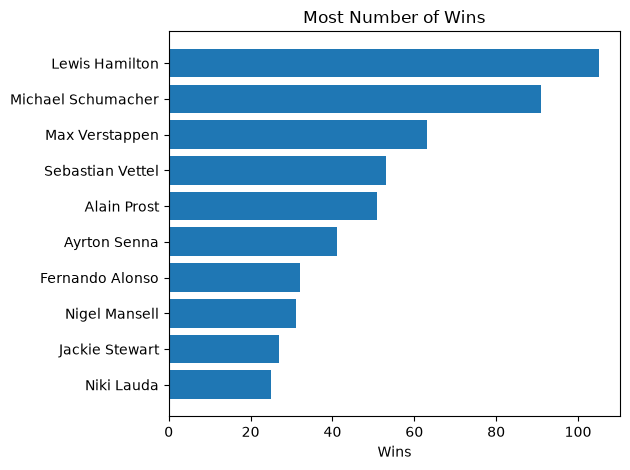

In [81]:
# Analysis 1A: Driver with most race wins

drivers_cleaned = pd.read_csv('Cleaned_datasets/drivers_cleaned.csv')
results_cleaned = pd.read_csv('Cleaned_datasets/results_cleaned.csv')

winners = results_cleaned[results_cleaned['position'] == 1]

top_drivers = winners.groupby('driverId').size().reset_index(name='Wins')

top_drivers = pd.merge(top_drivers, drivers_cleaned[['driverId', 'forename', 'surname']], on='driverId')

top_drivers['Name'] = top_drivers['forename'] + ' ' + top_drivers['surname']

top_drivers = top_drivers.sort_values('Wins', ascending=False).head(10)


# Plotting
plt.barh(top_drivers['Name'], top_drivers['Wins'])
plt.xlabel("Wins")
plt.title("Most Number of Wins")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

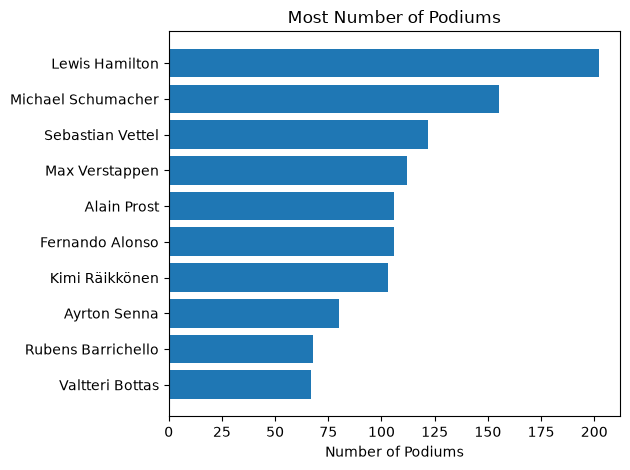

In [80]:
# Analysis 1B: Drivers with most podium finishes

drivers_cleaned = pd.read_csv('Cleaned_datasets/drivers_cleaned.csv')
results_cleaned = pd.read_csv('Cleaned_datasets/results_cleaned.csv')

podiums = results_cleaned[results_cleaned['position'].isin([1, 2, 3])]

podium_drivers = podiums.groupby('driverId').size().reset_index(name='Podiums')

podium_drivers = pd.merge(podium_drivers, drivers_cleaned[['driverId', 'forename', 'surname']], on='driverId')

podium_drivers['Name'] = podium_drivers['forename'] + ' ' + podium_drivers['surname']

podium_drivers = podium_drivers.sort_values('Podiums', ascending=False).head(10)



# Plotting
plt.barh(podium_drivers['Name'], podium_drivers['Podiums'])
plt.xlabel("Number of Podiums")
plt.title("Most Number of Podiums")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

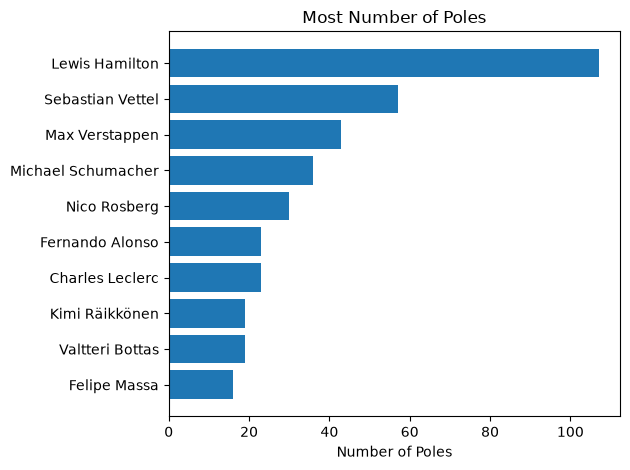

In [79]:
# Analysis 1C: Most pole positions

drivers_cleaned = pd.read_csv('Cleaned_datasets/drivers_cleaned.csv')
qualifying_cleaned = pd.read_csv('Cleaned_datasets/qualifying_cleaned.csv')

most_pole = qualifying_cleaned[qualifying_cleaned['position'] == 1]

most_pole_drivers = most_pole.groupby('driverId').size().reset_index(name='Poles')

most_pole_drivers = pd.merge(most_pole_drivers, drivers_cleaned[['driverId', 'forename', 'surname']], on='driverId')

most_pole_drivers['Name'] = most_pole_drivers['forename'] + ' ' + most_pole_drivers['surname']

most_pole_drivers = most_pole_drivers.sort_values('Poles', ascending=False).head(10)




# Plotting
plt.barh(most_pole_drivers['Name'], most_pole_drivers['Poles'])
plt.xlabel("Number of Poles")
plt.title("Most Number of Poles")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

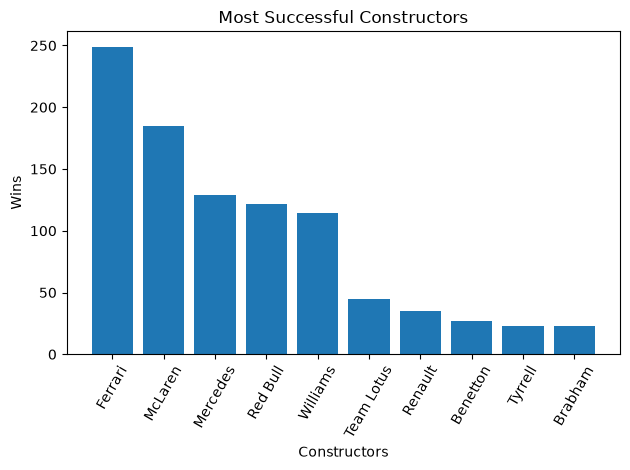

In [5]:
# Analysis 2A: Most successful teams

constructors_cleaned = pd.read_csv('Cleaned_datasets/constructors_cleaned.csv')
results_cleaned = pd.read_csv('Cleaned_datasets/results_cleaned.csv')

wins = results_cleaned[results_cleaned['position'] == 1]

top_teams = wins.groupby('constructorId').size().reset_index(name='Wins')

top_teams = pd.merge(top_teams, constructors_cleaned[['constructorId', 'name']], on='constructorId')

top_teams = top_teams.sort_values("Wins", ascending=False).head(10)




# Plotting
plt.bar(top_teams['name'], top_teams['Wins'])
plt.title("Most Successful Constructors")
plt.xlabel("Constructors")
plt.ylabel("Wins")
plt.xticks(rotation=60)
plt.tight_layout()
plt.show()

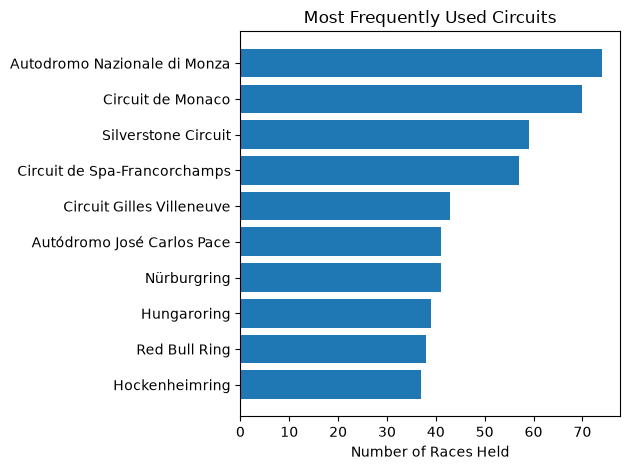

In [78]:
# Analysis 3A: Most frequently used circuits

races_cleaned = pd.read_csv('Cleaned_datasets/races_cleaned.csv')
circuits_cleaned = pd.read_csv('Cleaned_datasets/circuits_cleaned.csv')

venues = races_cleaned[['circuitId']]

top_venues = venues.groupby('circuitId').size().reset_index(name='Frequency')

top_venues = pd.merge(top_venues, circuits_cleaned[['circuitId', 'name']], on='circuitId')

top_venues = top_venues.sort_values('Frequency', ascending=False).head(10)





# Plotting
plt.barh(top_venues['name'], top_venues['Frequency'])
plt.xlabel("Number of Races Held")
plt.title("Most Frequently Used Circuits")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


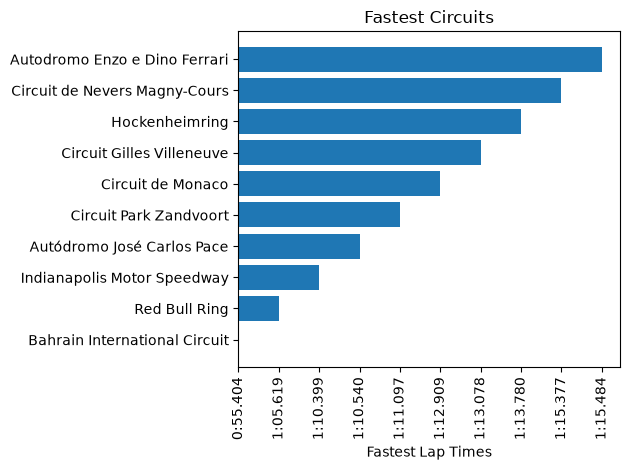

In [132]:
# Analysis 3B: Fastest Circuits

circuits_cleaned = pd.read_csv('Cleaned_datasets/circuits_cleaned.csv')
races_cleaned = pd.read_csv('Cleaned_datasets/races_cleaned.csv')
results_cleaned = pd.read_csv('Cleaned_datasets/results_cleaned.csv')

races_and_circuits = pd.merge(races_cleaned[['raceId', 'circuitId']], circuits_cleaned[['circuitId', 'name']], on='circuitId')
races_and_circuits.head()

circuits_and_laps = pd.merge(races_and_circuits, results_cleaned[['raceId', 'fastestLapTime']], on='raceId')
circuits_and_laps.head(50)

def lap_to_seconds(lap):
    if pd.isna(lap):
        return np.nan

    mins, secs = lap.split(':')
    return int(mins) * 60 + float(secs)

def seconds_to_lap(seconds):
    mins = int(seconds // 60)
    secs = seconds % 60
    return f"{mins}:{secs:06.3f}"


circuits_and_laps = circuits_and_laps[circuits_and_laps['fastestLapTime'] != '\\N']
circuits_and_laps['lap_seconds'] = circuits_and_laps['fastestLapTime'].apply(lap_to_seconds)

fastest_circuits = circuits_and_laps.groupby('name')['lap_seconds'].min().reset_index()
fastest_circuits = fastest_circuits.dropna()
                                   
fastest_circuits['Fastest Lap'] = fastest_circuits['lap_seconds'].apply(seconds_to_lap)
fastest_circuits = fastest_circuits.sort_values('Fastest Lap').head(10)




# Plotting
plt.barh(fastest_circuits['name'], fastest_circuits['Fastest Lap'])
plt.xlabel("Fastest Lap Times")
plt.xticks(rotation=90)
plt.title("Fastest Circuits")
plt.tight_layout()
plt.show()

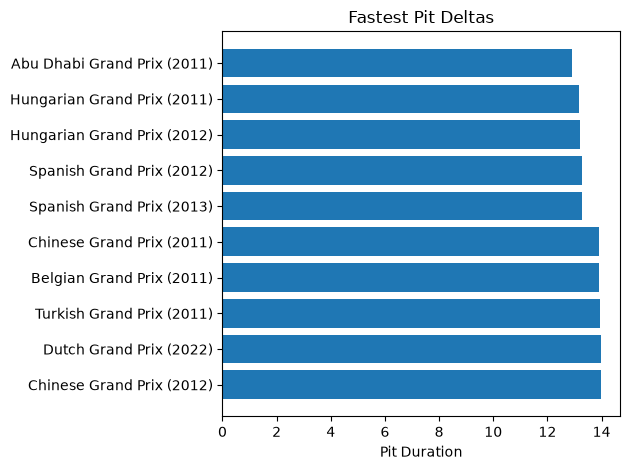

In [76]:
# Analysis 4A: Fastest Pitstops

pit_stops_cleaned = pd.read_csv("Cleaned_datasets/pit_stops_cleaned.csv")
races_cleaned = pd.read_csv("Cleaned_datasets/races_cleaned.csv")

# Converting duration (str) into (int64)
pit_stops_cleaned['duration'] = pd.to_numeric(
    pit_stops_cleaned['duration'],
    errors='coerce'
)

all_pits_and_race_id = pd.merge(
    pit_stops_cleaned[['raceId', 'driverId', 'duration']], 
    races_cleaned[['raceId', 'year', 'name']], 
    on='raceId'
)

fastest_pit_and_race_id = all_pits_and_race_id.groupby('raceId')['duration'].min().reset_index()

pit_info_and_race = pd.merge(
    fastest_pit_and_race_id, 
    races_cleaned[['raceId', 'name', 'year']], 
    on='raceId'
)

pit_info_and_race = pit_info_and_race.sort_values('duration').head(10)
pit_info_and_race['Race'] = pit_info_and_race['name'] + ' (' + pit_info_and_race['year'].astype(str) +')'

# Plotting
plt.barh(pit_info_and_race['Race'], pit_info_and_race['duration'])
plt.xlabel("Pit Duration")
plt.title("Fastest Pit Deltas")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


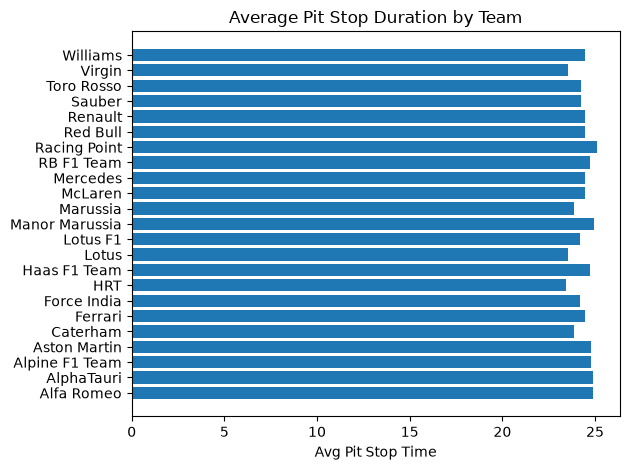

In [104]:
# Analysis 4B: Average pit stop duration by team

pit_stops_cleaned = pd.read_csv("Cleaned_datasets/pit_stops_cleaned.csv")
results_cleaned = pd.read_csv("Cleaned_datasets/results_cleaned.csv")
constructors_cleaned = pd.read_csv('Cleaned_datasets/constructors_cleaned.csv')

# Converting duration (str) into (int64)
pit_stops_cleaned['duration'] = pd.to_numeric(pit_stops_cleaned['duration'], errors='coerce')

pit_and_constructor = pd.merge(pit_stops_cleaned[['raceId', 'duration']], results_cleaned[['raceId', 'constructorId']], on='raceId')
pit_and_constructor = pd.merge(pit_and_constructor, constructors_cleaned[['constructorId', 'name']], on='constructorId')

pit_and_constructor = pit_and_constructor.groupby(['name'])['duration'].mean().reset_index(name='duration')




# Plotting
plt.barh(pit_and_constructor['name'], pit_and_constructor['duration'])
plt.xlabel("Avg Pit Stop Time")
plt.title("Average Pit Stop Duration by Team")
plt.tight_layout()
plt.show()

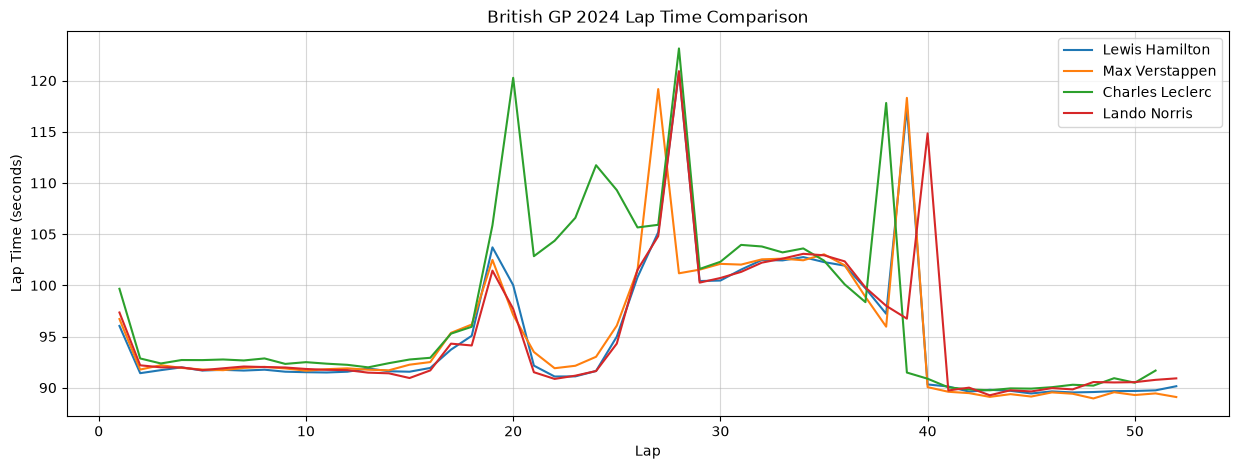

In [ ]:
# Analysis 5: Lap times of a particular driver (Lewis Hamilton) for a particular race (Silverstone 24')

lap_times_cleaned = pd.read_csv("Cleaned_datasets/lap_times_cleaned.csv")
races_cleaned = pd.read_csv("Cleaned_datasets/races_cleaned.csv")
drivers_cleaned = pd.read_csv("Cleaned_datasets/drivers_cleaned.csv")

lap_times_and_races = pd.merge(
    lap_times_cleaned[['raceId', 'driverId', 'lap', 'milliseconds']], 
    races_cleaned[['raceId', 'year', 'name']], 
    on='raceId'
)
drivers_cleaned['Driver Name'] = drivers_cleaned['forename'] + " " + drivers_cleaned['surname']

lap_races_and_drivers = pd.merge(
    lap_times_and_races, 
    drivers_cleaned[['driverId', 'Driver Name']], 
    on='driverId'
)

lap_races_and_drivers['Race details'] = lap_races_and_drivers['year'].astype(str) + " " + lap_races_and_drivers['name']
lap_races_and_drivers.drop(columns=['year', 'name'], inplace=True)
lap_races_and_drivers.head(10)

# Converting milliseconds into lap_time format
def ms_to_laptime(ms):
    mins = ms // 60000
    secs = (ms % 60000) / 1000
    return f"{mins}:{secs:06.3f}"

lap_races_and_drivers['Lap Time'] = lap_races_and_drivers['milliseconds'].apply(ms_to_laptime)
lap_races_and_drivers.head()

race_data = lap_races_and_drivers[lap_races_and_drivers['Race details'] == '2024 British Grand Prix']

ham = race_data[race_data['Driver Name'] == 'Lewis Hamilton']
maxi = race_data[race_data['Driver Name'] == 'Max Verstappen']
char = race_data[race_data['Driver Name'] == 'Charles Leclerc']
lan = race_data[race_data['Driver Name'] == 'Lando Norris']

# Plotting

plt.figure(figsize=(15,5))

plt.plot(ham['lap'], ham['milliseconds'] / 1000, label='Lewis Hamilton')
plt.plot(maxi['lap'], maxi['milliseconds'] / 1000, label='Max Verstappen')
plt.plot(char['lap'], char['milliseconds'] / 1000, label='Charles Leclerc')
plt.plot(lan['lap'], lan['milliseconds'] / 1000, label='Lando Norris')

plt.xlabel('Lap')
plt.ylabel('Lap Time (seconds)')
plt.title('British GP 2024 Lap Time Comparison')

plt.legend()
plt.grid(alpha=0.5)

plt.show()